# Assignment 2 Solution

## 作业要求解读

本次作业要求你用 Keras 构建一个前馈神经网络，并严格满足下面这些约束：

1. 输入层有 2 个输入，对应输入向量 `[0.05, 0.1]`。
2. 模型需要有 **3 个隐藏层**，并且 **每个隐藏层只有 2 个神经元**。
3. 输出层有 2 个神经元，对应目标输出 `[0.01, 0.99]`。
4. 隐藏层和输出层都要使用 `sigmoid` 激活函数，并且包含 bias。Keras 的 `Dense` 默认 `use_bias=True`，所以这里已经满足。
5. 训练数据不是很多不同样本，而是把同一个输入 `[0.05, 0.1]` 和输出 `[0.01, 0.99]` 重复生成 1000 次。
6. 损失函数必须使用 `MSE`。
7. 优化器必须使用 `Adam`。
8. 训练参数必须设置为 `epochs=10`、`batch_size=1`、`shuffle=True`。
9. 需要固定随机种子，保证结果可复现。
10. 需要在 notebook 中画出训练损失曲线。

下面的代码单元已经按这些要求逐项实现，并在关键步骤旁做了注释。

In [1]:
# Step 1: import required libraries
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Use tf.keras directly to avoid import issues in some local environments
keras = tf.keras
layers = tf.keras.layers

# Step 2: fix random seed for reproducibility (assignment requirement)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Random seed fixed at: {SEED}")

2026-03-30 20:29:25.770999: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Random seed fixed at: 42


In [2]:
# Step 3: create the same 1000 samples of input and output (assignment requirement)
single_input = np.array([0.05, 0.1], dtype=np.float32)
single_target = np.array([0.01, 0.99], dtype=np.float32)

X = np.tile(single_input, (1000, 1))
y = np.tile(single_target, (1000, 1))

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("First input sample:", X[0])
print("First target sample:", y[0])

Input shape: (1000, 2)
Target shape: (1000, 2)
First input sample: [0.05 0.1 ]
First target sample: [0.01 0.99]


In [3]:
# Step 4: build the neural network with the exact structure required in the assignment
# - 2 inputs
# - 3 hidden layers
# - each hidden layer has 2 neurons
# - output layer has 2 neurons
# - hidden and output activations are sigmoid
# - Dense uses bias by default (use_bias=True)

model = keras.Sequential([
    keras.Input(shape=(2,), name="input_layer"),
    layers.Dense(2, activation="sigmoid", use_bias=True, name="hidden_layer_1"),
    layers.Dense(2, activation="sigmoid", use_bias=True, name="hidden_layer_2"),
    layers.Dense(2, activation="sigmoid", use_bias=True, name="hidden_layer_3"),
    layers.Dense(2, activation="sigmoid", use_bias=True, name="output_layer")
])

# Step 5: compile the model
# Assignment requirement:
# - loss must be MSE
# - optimizer must be Adam
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24 (96.00 B)

 Trainable params: 24 (96.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Step 6: train the model with the exact hyperparameters required in the assignment
# Required settings:
# - epochs = 10
# - batch_size = 1
# - shuffle = True

history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=1,
    shuffle=True,
    verbose=1
)


Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1640
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 949us/step - loss: 0.0163
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step - loss: 0.0036
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - loss: 0.0012
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - loss: 5.0540e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 800us/step - loss: 2.1859e-04
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - loss: 9.4090e-05
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - loss: 3.8298e-05
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - loss: 1.4003e-05
Epoch 10/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - loss: 4.2988e-06


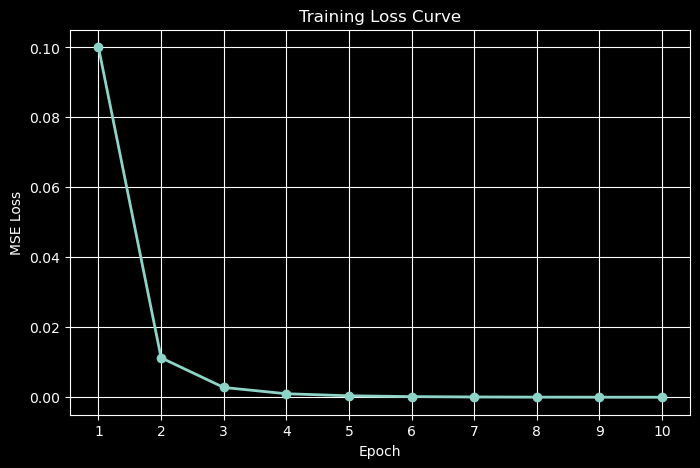

In [5]:
# Step 7: plot training loss curve (assignment requirement)
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xticks(range(10), range(1, 11))
plt.grid(True)
plt.show()

In [6]:
# Step 8: check model prediction for the required input sample
prediction = model.predict(np.array([[0.05, 0.1]], dtype=np.float32), verbose=0)
print("Prediction for [0.05, 0.1]:", prediction[0])
print("Target output: [0.01, 0.99]")

Prediction for [0.05, 0.1]: [0.01166556 0.98972   ]
Target output: [0.01, 0.99]


## 提交前检查

你可以按下面的清单核对是否完全满足作业要求：

- 使用了 Keras 建模。
- 输入维度为 2。
- 有 3 个隐藏层，每层 2 个神经元。
- 输出层有 2 个神经元。
- 隐藏层和输出层都使用 `sigmoid`。
- 训练集是 1000 个重复样本。
- `loss='mse'`。
- `optimizer=Adam()`。
- `epochs=10`，`batch_size=1`，`shuffle=True`。
- 固定了随机种子。
- 已绘制训练损失曲线。

最后按老师要求，把文件名改成 `firstName_lastName.ipynb` 再提交。